# DEMI | NOVA FCT

## Fatigue Design of Mechanical Joints and Aerospace Structures

##### José Xavier & Rui Martins

### Problems 4 — Fatigue crack growth (Paris law)

- [Exercise 4.1](#ex1) — Conceptual questions on fatigue crack growth
- [Exercise 4.2](#ex2) — Paris law: units and sensitivity
- [Exercise 4.3](#ex3) — Crack closure and $R$-ratio effects
- [Exercise 4.4](#ex4) — Paris-law integration for a CCT panel (core T1)
- [Exercise 4.5](#ex5) — Paris law recovers the S–N power law
- [Exercise 4.6](#ex6) — Incremental crack growth with width correction


---

## Formulary — Paris law and integration

**Paris–Erdogan:**
\begin{equation*}
\dfrac{\mathrm{d}a}{\mathrm{d}N} = C\,(\Delta K)^{m},
\qquad \Delta K = Y\,\Delta\sigma\,\sqrt{\pi a}.
\tag{F.1}\end{equation*}

**Refined Feddersen $Y(a/W)$ for CCT:**
\begin{equation*}
Y(a/W) = \left[1-0.1(a/W)^{2}+0.96(a/W)^{4}\right]\sqrt{\sec(\pi a/W)}.
\tag{F.2}\end{equation*}

**Life by integration:**
\begin{equation*}
N_{f} = \int_{a_{0}}^{a_{c}}\dfrac{\mathrm{d}a}{C\,[\Delta K(a)]^{m}}.
\tag{F.3}\end{equation*}

**Critical crack** ($K_{\max}=K_{IC}$):
\begin{equation*}
Y\!\left(\dfrac{a_{c}}{W}\right)\,\dfrac{\Delta\sigma}{1-R}\,\sqrt{\pi a_{c}} = K_{IC}.
\tag{F.4}\end{equation*}

**Paris ↔ S–N for $Y=1$, $a_{c}\gg a_{0}$:** $N_{f}\propto(\Delta\sigma)^{-m}$, recovering
$(\Delta\sigma)^{m}\,N_{f}=\text{const}$ with the S–N slope equal to the Paris $m$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Latex, Markdown, display

FS = 14

# Reset to default style so any IDE dark-theme overrides do not bleed in.
plt.style.use('default')

plt.rcParams.update({
    'figure.figsize':   (10, 4.2), 'figure.dpi': 110,
    'font.family':      'serif',  'font.size': FS,
    'axes.grid':        True,     'grid.alpha': 0.30,
    'lines.linewidth':  2,
    # --- Backgrounds (white) ---
    'axes.facecolor':   'white',
    'figure.facecolor': 'white',
    'savefig.facecolor':'white',
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black',
    # --- Force all text BLACK so the IDE dark theme does not hide it ---
    'text.color':       'black',
    'axes.labelcolor':  'black',
    'axes.edgecolor':   'black',
    'axes.titlecolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    'legend.labelcolor':'black',
})

COLORS = dict(curve='#1f4e79', point='#c0392b', accent='#8e44ad',
              guide='0.55',    warn='#e67e22', cool='#16a085')

SQRT1000 = np.sqrt(1000.0)         # 1 MPa√m = √1000 N·mm^(-3/2)

def Y_feddersen_DK(aW):
    """Refined Feddersen Y(a/W) for ΔK (eq F.2 of the formulary)."""
    aw = np.asarray(aW, dtype=float)
    return (1 - 0.1*aw**2 + 0.96*aw**4)*np.sqrt(1.0/np.cos(np.pi*aw))


<a id='ex1'></a>
---

## Exercise 4.1 — Conceptual questions on fatigue crack growth

**Conceptual questions on fatigue crack growth**

**(a)** Which conditions must be satisfied for the application of the similitude concept to predict fatigue crack growth in a component under constant-amplitude loading?

**(b)** Describe the three regions of a typical $\mathrm{d}a/\mathrm{d}N$ vs. $\Delta K$ plot (log--log). What physical mechanism dominates in each region?

**(c)** What is the threshold stress intensity factor range $\Delta K_{\text{th}}$? What is the “small crack” problem associated with $\Delta K_{\text{th}}$?

**(d)** How should constant-$\Delta K$ tests be carried out? What is one advantage and one disadvantage of this type of test?

### Solution

**(a) Similitude conditions for $\Delta K$-based prediction.**

* Linear-elastic conditions at the crack tip — small-scale yielding
  ($r_{p}\ll a, W-a, B$).
* Same material, environment and temperature as the source data set.
* Same Mode (I, II or III).
* Same load ratio $R$ — or use $\Delta K_{\text{eff}}$ to remove $R$-dependence.
* Long-crack regime (no small-crack effects).
* Constant-amplitude loading (no overload/underload interaction).

**(b) Three regions on $\log(\mathrm{d}a/\mathrm{d}N)$ vs. $\log(\Delta K)$.**

| Region | Mechanism |
|---|---|
| I — near-threshold | Microstructure-controlled, slip-band initiation; rate drops to ~0 below $\Delta K_{\text{th}}$. |
| II — Paris regime  | Striation-dominated propagation; linear log–log; well described by $\mathrm{d}a/\mathrm{d}N = C(\Delta K)^{m}$. |
| III — accelerated  | $K_{\max}\to K_{IC}$; static fracture mechanisms (cleavage, dimple rupture) add to fatigue striations; curve bends upward. |

**(c) Threshold $\Delta K_{\text{th}}$ and small-crack problem.**

$\Delta K_{\text{th}}$ is the smallest $\Delta K$ below which fatigue crack growth is
not detectable (typically defined at $10^{-10}$ m/cycle).

The "small-crack" problem: **microscopically short cracks** ($a$ comparable to
grain size) violate similitude — they propagate at rates *higher* than the
long-crack $\Delta K$ would predict and below the apparent threshold. They are
relevant for life predictions starting from microstructural defects.

**(d) Constant-$\Delta K$ tests.**

Performed by **continuously reducing the applied load** as $a$ grows so that
$\Delta K = Y\Delta\sigma\sqrt{\pi a}$ stays constant. Advantage: clean
isolation of $\Delta K$ as the single driving force, ideal for studying
near-threshold and environmental effects. Disadvantage: requires closed-loop
servo-hydraulic control; not representative of real loading; transition
artefacts when load levels change abruptly.


<a id='ex2'></a>
---

## Exercise 4.2 — Paris law: units and sensitivity

**Paris law: units and sensitivity**

The Paris relation for SAE 4340 steel can be written as:

$$
\frac{\mathrm{d}a}{\mathrm{d}N} = 17.9\times10^{-6}\;(\Delta K)^{2.675}
$$

with $\mathrm{d}a/\mathrm{d}N$ in mm/kcycle and $\Delta K$ in MPa$\sqrt{\text{m}}$.

**(a)** Rewrite this relation using the units: $\mathrm{d}a/\mathrm{d}N$ in inch/cycle and $\Delta K$ in ksi$\sqrt{\text{in}}$.

**(b)** Are the constants $C$ and $m$ dependent on the unit system? Explain.

**(c)** A component is loaded under CA loading. If the stress level is increased by 30%, by what factor does the crack growth rate increase? Use the Paris exponent $m = 2.675$.

### Solution

#### (a) Convert to inch/cycle vs ksi√in

Two factors:

\begin{equation*}
1~\text{mm/kcycle} = \dfrac{1/25.4~\text{inch}}{10^{3}~\text{cycle}}
                  = 3.937\times 10^{-5}~\text{inch/cycle},
\tag{4.2.1}\end{equation*}

\begin{equation*}
1~\text{MPa}\sqrt{\text{m}} = \dfrac{1}{1.099}~\text{ksi}\sqrt{\text{in}}
                              \approx 0.910~\text{ksi}\sqrt{\text{in}}.
\tag{4.2.2}\end{equation*}

So, if $\Delta K^{\text{US}} = \Delta K/1.099$,

\begin{equation*}
\dfrac{\mathrm{d}a}{\mathrm{d}N}\bigg|_{\text{inch/cycle}}
   = 17.9\times 10^{-6}\times 3.937\times 10^{-5}\,(1.099\,\Delta K^{\text{US}})^{2.675}.
\tag{4.2.3}\end{equation*}


In [2]:
C_SI, m = 17.9e-6, 2.675       # mm/kcycle, MPa*sqrt(m)

# da/dN: 1 mm/kcycle = (1/25.4 in) / (1000 cycles) = 3.937e-5 inch/cycle
mm_to_in_per_kc_to_per_c = (1.0/25.4)/1000.0

# Delta_K: 1 MPa*sqrt(m) = 1/1.099 ksi*sqrt(in)  (1 ksi*sqrt(in) = 1.099 MPa*sqrt(m))
ksi_per_MPa = 1.0/1.099

# Converting:  da/dN [inch/cycle] = C_SI x (da factor) x (dK factor)^m
#              because C x DK^m => C x (1.099 DK_US)^m
dK_factor = 1.099**m
C_US = C_SI * mm_to_in_per_kc_to_per_c * dK_factor

print(f'(a) da/dN unit factor: 1 mm/kcycle = 1/(25.4 x 1000) inch/cycle = {mm_to_in_per_kc_to_per_c:.3e} inch/cycle')
print(f'    DK unit factor   : 1 MPa*sqrt(m) = 1/1.099 ksi*sqrt(in)  =>  1.099^m = 1.099^{m} = {dK_factor:.5f}')
print(f'    C_US = C_SI x (da factor) x (DK factor)^m')
print(f'         = {C_SI:.4e} x {mm_to_in_per_kc_to_per_c:.3e} x {dK_factor:.5f}')
print(f'         = {C_US:.3e}  (inch/cycle, ksi*sqrt(in))')
print(f'    Exponent m = {m} (dimensionless — unchanged)')


(a) da/dN unit factor: 1 mm/kcycle = 1/(25.4 x 1000) inch/cycle = 3.937e-05 inch/cycle
    DK unit factor   : 1 MPa*sqrt(m) = 1/1.099 ksi*sqrt(in)  =>  1.099^m = 1.099^2.675 = 1.28727
    C_US = C_SI x (da factor) x (DK factor)^m
         = 1.7900e-05 x 3.937e-05 x 1.28727
         = 9.072e-10  (inch/cycle, ksi*sqrt(in))
    Exponent m = 2.675 (dimensionless — unchanged)


#### (b) Are $C$ and $m$ unit-dependent?

* $m$ is **dimensionless** and is the same in any consistent unit system.
* $C$ **does** depend on the units, since it carries the dimensions
  $[\text{length}]^{1-m/2}\,[\text{stress}]^{-m}$. Converting either
  $\mathrm{d}a/\mathrm{d}N$ or $\Delta K$ changes $C$.

#### (c) Sensitivity: +30 % in $\Delta\sigma$


In [3]:
factor = 1.30**m
print(f'(c) DK = Y*Dsigma*sqrt(pi*a),  so DK increases by the same factor as Dsigma (linear)')
print(f'    Dsigma increases by 30%  =>  DK increases by 30%')
print(f'    da/dN factor = (1.30)^m = (1.30)^{m} = {factor:.4f}')
print(f'                ~ {(factor-1)*100:.0f}% increase in crack growth rate per cycle')


(c) DK = Y*Dsigma*sqrt(pi*a),  so DK increases by the same factor as Dsigma (linear)
    Dsigma increases by 30%  =>  DK increases by 30%
    da/dN factor = (1.30)^m = (1.30)^2.675 = 2.0174
                ~ 102% increase in crack growth rate per cycle


<a id='ex3'></a>
---

## Exercise 4.3 — Crack closure and $R$-ratio effects

**Crack closure and $R$-ratio effects**

**(a)** Explain the concept of crack closure (Elber). What is $\Delta K_{\text{eff}}$ and how does it differ from $\Delta K$?

**(b)** Is the $\mathrm{d}a/\mathrm{d}N = f(\Delta K)$ relation affected by the stress ratio $R$? Why?

**(c)** Is crack growth affected by the material thickness? Explain in terms of plane stress vs. plane strain at the crack tip.

**(d)** Under what circumstances can the $R$-dependence be eliminated by using $\Delta K_{\text{eff}}$?

### Solution

**(a) Crack closure (Elber, 1970).**

During unloading, the crack faces come into contact at a stress
$\sigma_{\text{op}}>\sigma_{\min}$ — i.e. the crack closes *before* the load
reaches its minimum. Below $\sigma_{\text{op}}$ the crack tip is shielded
from the load, so the effective driving force is reduced:

\begin{equation*}
\Delta K_{\text{eff}} = K_{\max} - K_{\text{op}} = U(R)\,\Delta K,\qquad 0<U(R)\le 1.
\tag{4.3.1}\end{equation*}

**(b) Effect of $R$.** Yes — at low $R$ (high closure) $\Delta K_{\text{eff}} < \Delta K$;
at high $R$ the crack remains open throughout the cycle, $U\to 1$ and the
$R$-dependence vanishes.

**(c) Thickness effect.** Thick (plane strain) crack tips have less plastic
deformation and less plasticity-induced closure → lower $U$, but typically
also lower toughness, so the net effect on $\mathrm{d}a/\mathrm{d}N$ is
material-dependent. Thin sheets (plane stress) develop more closure → lower
$\Delta K_{\text{eff}}$ and **slower** crack growth.

**(d) When does $\Delta K_{\text{eff}}$ collapse all $R$-data?**

When plasticity-induced closure is the only source of $R$-dependence: in
ductile metals at intermediate $R$. Other closure mechanisms
(roughness-induced, oxide-induced, fluid-induced) and Stage-III contributions
near $K_{IC}$ are not captured by $\Delta K_{\text{eff}}$ alone.


<a id='ex4'></a>
---

## Exercise 4.4 — Paris-law integration for a CCT panel (core T1)

**Paris law integration for a CCT panel**

Consider the rectangular plate of width $W = 100$ mm shown in Figure 4.4, containing a central through-thickness crack of initial total length $2a_0 = 1$ mm. The plate is made of a carbon steel (0.13%C) with yield stress $\sigma_e = 326$ MPa and fracture toughness $K_{\text{IC}} = 50\;\text{MPa}\sqrt{\text{m}}$. The plate is subjected to constant-amplitude fatigue loading with:

$$
\Delta\sigma = 200\;\text{MPa}, \qquad R = 0.25.
$$

The Paris law for this material is:

$$
\frac{\mathrm{d}a}{\mathrm{d}N} = 1\times10^{-15}\;(\Delta K)^{3}
$$

with $\mathrm{d}a/\mathrm{d}N$ in mm/cycle and $\Delta K$ in N$\cdot$mm$^{-3/2}$.

The stress intensity factor range is given by Eq. (4.2).

**(a)** Compute the maximum stress $\sigma_{\max}$ from $\Delta\sigma$ and $R$.

**(b)** Determine the critical crack half-length $a_c$ by solving $K_{\max}(a_c) = K_{\text{IC}}$ numerically (or iteratively).

**(c)** Implement the cycle-by-cycle (or incremental $\Delta a$) numerical integration of the Paris law from $a_0$ to $a_c$ using Python. Use a fixed crack increment $\Delta a$ (*e.g.* 0.1 mm) and the forward Euler scheme:

$$
\Delta N_i = \frac{\Delta a}{C\,[\Delta K(a_i)]^m}, \qquad N_{i+1} = N_i + \Delta N_i, \qquad a_{i+1} = a_i + \Delta a.
$$

**(d)** Plot $a$ vs. $N$ and $\mathrm{d}a/\mathrm{d}N$ vs. $\Delta K$ (log--log) from your numerical integration.

**(e)** Report the total fatigue life $N_f$ (number of cycles from $a_0$ to $a_c$).

**(f)** Verify the convergence of your solution by reducing $\Delta a$ by a factor of 2 and comparing $N_f$.

*Figure 4.4 — Central-cracked tension (CCT) panel of width $W$ with a through-thickness central crack of total length $2a$, subjected to remote constant-amplitude cyclic stress of range $\Delta\sigma$ and stress ratio $R = \sigma_{\min}/\sigma_{\max}$. The crack length is exaggerated for clarity ($2a_0/W = 1/100$ in the problem).*

### Solution


#### (a) Maximum stress

\begin{equation*}
\sigma_{\max} = \dfrac{\Delta\sigma}{1-R} = \dfrac{200}{0.75} \approx 266.67~\text{MPa}.
\tag{4.4.1}\end{equation*}


In [4]:
W       = 100.0                      # mm
a0      = 0.5                         # mm  (half-length)
sigma_e = 326.0                       # MPa  (yield strength)
K_IC    = 50.0                        # MPa*sqrt(m)
dsigma  = 200.0                       # MPa  (stress range)
R       = 0.25
C, m    = 1e-15, 3                    # Paris (mm/cycle, N*mm^(-3/2))

sigma_max = dsigma/(1-R)
sigma_min = R*sigma_max
print(f'(a) sigma_max = Dsigma/(1-R) = {dsigma:.1f}/(1-{R}) = {dsigma:.1f}/{1-R:.2f} = {sigma_max:.2f} MPa')
print(f'    sigma_min = R x sigma_max = {R} x {sigma_max:.2f} = {sigma_min:.2f} MPa')


(a) sigma_max = Dsigma/(1-R) = 200.0/(1-0.25) = 200.0/0.75 = 266.67 MPa
    sigma_min = R x sigma_max = 0.25 x 266.67 = 66.67 MPa


#### (b) Critical crack length $a_{c}$

Solve $Y(a_{c}/W)\,\sigma_{\max}\,\sqrt{\pi a_{c}} = K_{IC}\sqrt{1000}$
(LHS in N·mm⁻³ᐟ²). Bisection on $a_{c}\in[a_{0}, W/2]$.


In [5]:
# ============================================================
# (b) Critical half-crack length a_c
# ------------------------------------------------------------
# We solve   K_max(a_c) = K_IC            (in N·mm^(-3/2))
# i.e.       Y(a_c/W) * sigma_max * sqrt(pi * a_c)  =  K_IC * sqrt(1000)
#
# Why bisection, and why these bounds?
#   * lo = a_0       : initial half-crack.
#                      f(lo) = K_max(a_0) - K_IC  < 0   (subcritical)
#   * hi = W/2 - eps : Feddersen's Y(a/W) carries sqrt(sec(pi a / W)),
#                      which DIVERGES at a/W = 1/2 (cos(pi/2) = 0).
#                      We stop a hair short of the singularity, taking
#                      eps = 1e-3 mm.   f(hi) = K_max(hi) - K_IC  >> 0.
#   K_max(a) is continuous and monotonically increasing on the bracket,
#   so a unique root exists between lo and hi.
# ============================================================

K_IC_Nmm = K_IC * SQRT1000            # 50 MPa√m  ->  N·mm^(-3/2)

def K_max_Nmm(a_mm):
    aw = a_mm / W
    return Y_feddersen_DK(aw) * sigma_max * np.sqrt(np.pi * a_mm)

# ---- Bisection with tolerance and convergence log -----------------
EPS_HI  = 1e-3        # mm   - keep clear of the Feddersen singularity
TOL_MM  = 1e-6        # mm   - stop when (hi - lo) < TOL_MM
MAX_IT  = 80

lo, hi   = a0, W/2 - EPS_HI
f_lo, f_hi = K_max_Nmm(lo) - K_IC_Nmm, K_max_Nmm(hi) - K_IC_Nmm
assert f_lo < 0 < f_hi, 'initial bracket does not enclose the root'

hist = []                                 # (it, lo, hi, mid, K_mid_MPa, bracket)
for it in range(1, MAX_IT + 1):
    mid     = 0.5 * (lo + hi)
    K_mid   = K_max_Nmm(mid)
    bracket = hi - lo
    hist.append((it, lo, hi, mid, K_mid / SQRT1000, bracket))
    if K_mid < K_IC_Nmm:
        lo = mid
    else:
        hi = mid
    if bracket < TOL_MM:
        break
a_c = 0.5 * (lo + hi)

# ---- Compact convergence table (first 4 + last 4 iterations) ------
print(f'(b) Bisection on [a_0 = {a0:.3f} mm,  W/2 - eps = {W/2-EPS_HI:.3f} mm]')
print(f'    Target K_IC = {K_IC:.2f} MPa√m   (= {K_IC_Nmm:.1f} N·mm^(-3/2))\n')
hdr = f'    {"it":>3} {"lo (mm)":>10} {"hi (mm)":>10} {"mid (mm)":>10} ' \
      f'{"K_max(mid) [MPa√m]":>20} {"hi-lo (mm)":>12}'
print(hdr)
print('    ' + '-'*(len(hdr)-4))
n     = len(hist)
shown = list(range(min(4, n))) + (list(range(max(4, n-4), n)) if n > 8 else [])
prev  = -1
for k in shown:
    if k - prev > 1:
        print(f'    {"...":>3}')
    it, l, h, mi, Kmi, br = hist[k]
    print(f'    {it:3d} {l:10.4f} {h:10.4f} {mi:10.4f} {Kmi:20.4f} {br:12.2e}')
    prev = k

print(f'\n    Converged after {n} iterations  (bracket < {TOL_MM:.0e} mm)')
print(f'    a_c        = {a_c:.4f} mm     (2 a_c = {2*a_c:.3f} mm)')
print(f'    a_c / W    = {a_c/W:.4f}')
print(f'    Y(a_c/W)   = {Y_feddersen_DK(a_c/W):.4f}')
print(f'    K_max(a_c) = {K_max_Nmm(a_c)/SQRT1000:.4f} MPa√m   '
      f'(target K_IC = {K_IC} MPa√m)')

(b) Bisection on [a_0 = 0.500 mm,  W/2 - eps = 49.999 mm]
    Target K_IC = 50.00 MPa√m   (= 1581.1 N·mm^(-3/2))

     it    lo (mm)    hi (mm)   mid (mm)   K_max(mid) [MPa√m]   hi-lo (mm)
    ----------------------------------------------------------------------
      1     0.5000    49.9990    25.2495              89.4474     4.95e+01
      2     0.5000    25.2495    12.8748              55.8568     2.47e+01
      3     0.5000    12.8748     6.6874              39.0673     1.24e+01
      4     6.6874    12.8748     9.7811              47.8384     6.19e+00
    ...
     24    10.5973    10.5973    10.5973              50.0000     5.90e-06
     25    10.5973    10.5973    10.5973              50.0000     2.95e-06
     26    10.5973    10.5973    10.5973              50.0000     1.48e-06
     27    10.5973    10.5973    10.5973              50.0000     7.38e-07

    Converged after 27 iterations  (bracket < 1e-06 mm)
    a_c        = 10.5973 mm     (2 a_c = 21.195 mm)
    a_c / W    = 0.

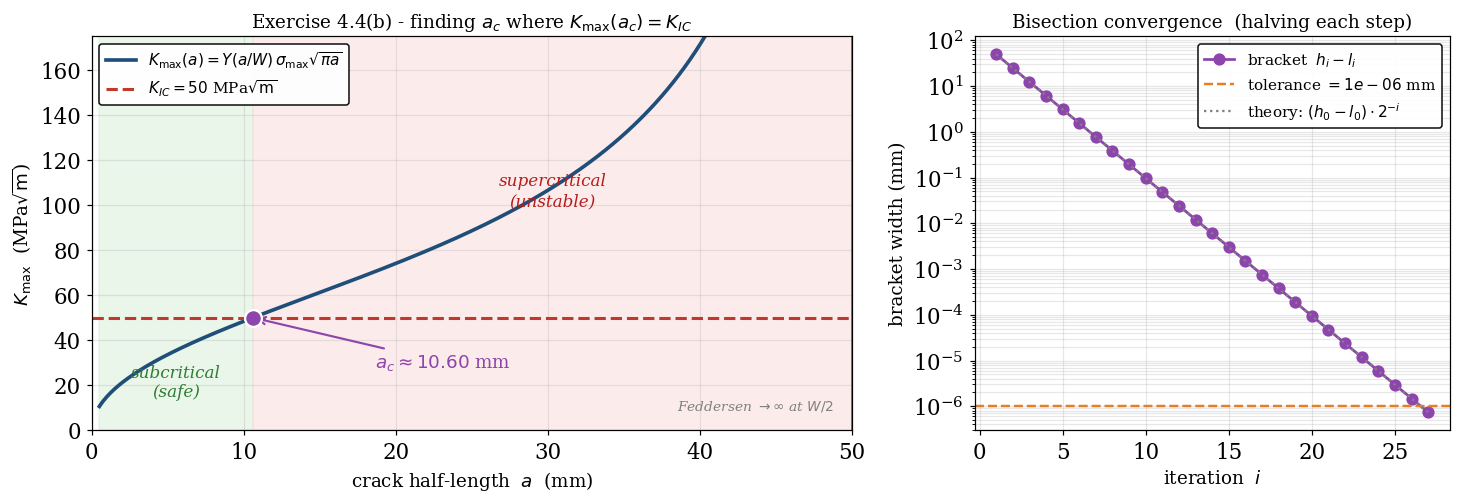

In [6]:
# ============================================================
# (b) Visualisation - two panels:
#   (left)  K_max(a) vs a, with K_IC line and a_c marked
#   (right) bisection convergence (bracket vs iteration, log scale)
# ============================================================

a_grid = np.linspace(a0, W/2 - EPS_HI, 400)
K_grid = np.array([K_max_Nmm(a) for a in a_grid]) / SQRT1000

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.8),
                                gridspec_kw={'width_ratios': [1.6, 1]})

ax1.axvspan(a0,  a_c,           color='#d8efd8', alpha=0.55, zorder=0)
ax1.axvspan(a_c, W/2 - EPS_HI,  color='#fadcdc', alpha=0.55, zorder=0)
ax1.plot(a_grid, K_grid, color=COLORS['curve'], lw=2.4,
         label=r'$K_{\max}(a) = Y(a/W)\,\sigma_{\max}\sqrt{\pi a}$')
ax1.axhline(K_IC, color=COLORS['point'], ls='--', lw=2,
            label=fr'$K_{{IC}} = {K_IC:.0f}$ MPa$\sqrt{{\mathrm{{m}}}}$')
ax1.plot([a_c], [K_IC], 'o', color=COLORS['accent'], ms=11, zorder=5,
         mec='white', mew=1.5)
ax1.annotate(fr'$a_c \approx {a_c:.2f}$ mm',
             xy=(a_c, K_IC), xytext=(a_c + 8, K_IC - 22),
             fontsize=12, color=COLORS['accent'],
             arrowprops=dict(arrowstyle='->', color=COLORS['accent'], lw=1.4))
ax1.text(a0 + 0.5*(a_c - a0), K_IC*0.30, 'subcritical\n(safe)',
         ha='center', fontsize=11, color='#2e7d32', style='italic')
ax1.text(a_c + 0.5*(W/2 - a_c), K_IC*2.0, 'supercritical\n(unstable)',
         ha='center', fontsize=11, color='#b71c1c', style='italic')
ax1.axvline(W/2, color='black', lw=1.0, alpha=0.6)
ax1.text(W/2 - 1.2, K_IC*0.18, r'Feddersen $\to\infty$ at $W/2$',
         ha='right', fontsize=9, color='gray', style='italic')

ax1.set_xlabel(r'crack half-length  $a$  (mm)', fontsize=12)
ax1.set_ylabel(r'$K_{\max}$  (MPa$\sqrt{\mathrm{m}}$)', fontsize=12)
ax1.set_title(r'Exercise 4.4(b) - finding $a_c$ where $K_{\max}(a_c) = K_{IC}$',
              fontsize=12)
ax1.set_xlim(0, W/2)
ax1.set_ylim(0, min(K_grid.max()*1.05, 3.5*K_IC))
ax1.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax1.grid(alpha=0.3, zorder=1)

its      = np.array([h[0] for h in hist])
brackets = np.array([h[5] for h in hist])
ax2.semilogy(its, brackets, 'o-', color=COLORS['accent'], lw=1.8, ms=7,
             label=r'bracket  $h_i - l_i$')
ax2.axhline(TOL_MM, color=COLORS['warn'], ls='--', lw=1.6,
            label=fr'tolerance $= {TOL_MM:.0e}$ mm')
theo = brackets[0]*0.5**(its - 1)
ax2.semilogy(its, theo, ':', color='gray', lw=1.5,
             label=r'theory: $(h_0 - l_0)\cdot 2^{-i}$')
ax2.set_xlabel('iteration  $i$', fontsize=12)
ax2.set_ylabel('bracket width (mm)', fontsize=12)
ax2.set_title('Bisection convergence  (halving each step)', fontsize=12)
ax2.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax2.grid(alpha=0.3, which='both')

plt.tight_layout(); plt.show()


#### (c)–(f) Forward-Euler integration with mesh convergence

Fixed crack increment $\Delta a$:

\begin{equation*}
\Delta N_{i} = \dfrac{\Delta a}{C\,[\Delta K(a_{i})]^{m}},
\qquad a_{i+1} = a_{i}+\Delta a,\;\;N_{i+1} = N_{i}+\Delta N_{i}.
\tag{4.4.2}\end{equation*}

We run the integrator for several $\Delta a$ values to (i) visualise the
while-loop output as trajectories $a(N)$, and (ii) check the mesh convergence
of the predicted life $N_f$ (forward Euler is first-order in $\Delta a$).

  delta_a (mm)   steps     N_f (cycles)    err vs finest
------------------------------------------------------------
         1.000      11       9.2757e+07          86.793%
         0.500      21       6.8626e+07          38.199%
         0.200      51       5.6250e+07          13.277%
         0.100     101       5.2643e+07           6.013%  <-- canonical
         0.050     202       5.0953e+07           2.609%
         0.025     404       5.0138e+07           0.967%
         0.010    1010       4.9658e+07           0.000%

(e) Canonical N_f (delta_a = 0.1 mm) = 5.264e+07 cycles
(f) Forward Euler is first-order: halving delta_a halves the error.


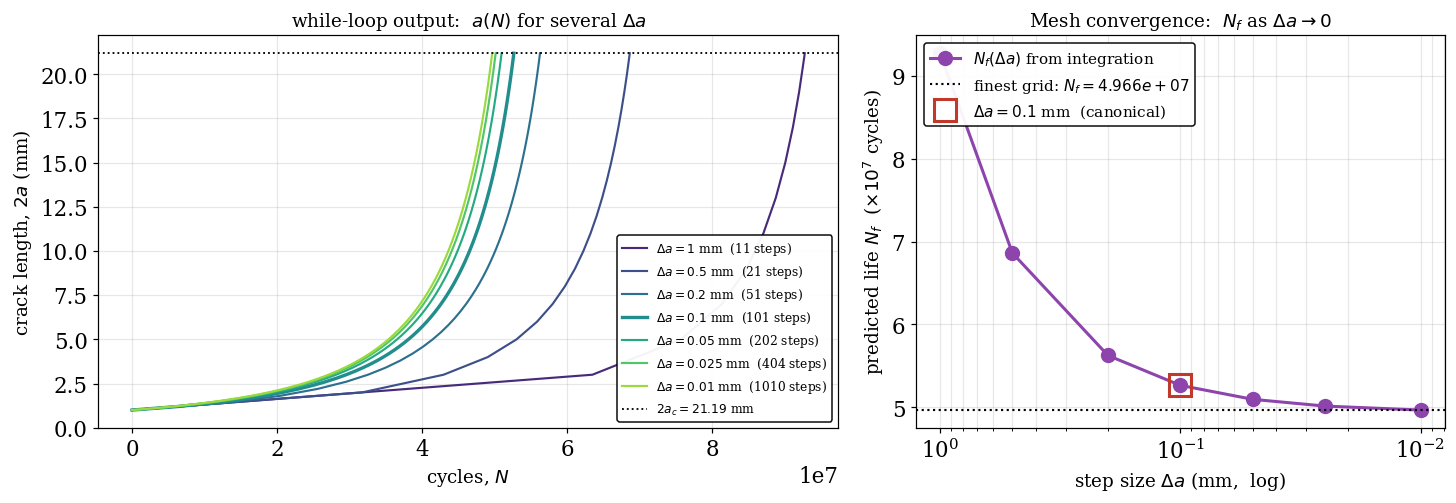

In [7]:
# ============================================================
# (c)-(f)  Forward-Euler integration with convergence study
# ============================================================

def integrate_paris(a0, ac, da, C, m, dsigma, W):
    """Forward-Euler integration of da/dN = C*(DK)^m on a CCT panel.
    Returns per-step arrays (a, N, dadN, dK)."""
    a, N = a0, 0.0
    a_list, N_list, dadN_list, dK_list = [a], [N], [], []
    while a < ac:
        Y    = float(Y_feddersen_DK(a/W))
        dK   = Y*dsigma*np.sqrt(np.pi*a)           # N·mm^(-3/2)
        dadN = C*dK**m                              # mm/cycle
        step = min(da, ac - a)                      # avoid overshoot
        dN   = step / dadN
        N += dN; a += step
        a_list.append(a); N_list.append(N)
        dadN_list.append(dadN); dK_list.append(dK)
    return (np.array(a_list), np.array(N_list),
            np.array(dadN_list), np.array(dK_list))

# --- Convergence study: shrinking delta_a ---
das  = np.array([1.0, 0.5, 0.2, 0.1, 0.05, 0.025, 0.01])
runs = {da: integrate_paris(a0, a_c, da, C, m, dsigma, W) for da in das}
Nf_arr = np.array([runs[d][1][-1]      for d in das])
steps  = np.array([len(runs[d][0]) - 1 for d in das])

# Canonical run (delta_a = 0.1 mm) used by the next cell (Paris plot).
a_arr, N_arr, dadN, dK = runs[0.1]
N_f = N_arr[-1]

# --- Convergence table ---
Nf_ref = Nf_arr[-1]   # take the finest grid as our reference
print(f'{"delta_a (mm)":>14} {"steps":>7} {"N_f (cycles)":>16} {"err vs finest":>16}')
print('-' * 60)
for d, ns, Nf in zip(das, steps, Nf_arr):
    err = (Nf - Nf_ref) / Nf_ref * 100
    marker = '  <-- canonical' if d == 0.1 else ''
    print(f'{d:14.3f} {ns:7d} {Nf:16.4e} {err:15.3f}%{marker}')
print(f'\n(e) Canonical N_f (delta_a = 0.1 mm) = {N_f:.3e} cycles')
print(f'(f) Forward Euler is first-order: halving delta_a halves the error.')

# --- Two-panel figure: trajectories + convergence ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.8),
                                gridspec_kw={'width_ratios': [1.4, 1]})

# LEFT: trajectories a(N) for every delta_a
cmap = plt.cm.viridis(np.linspace(0.12, 0.85, len(das)))
for d, color in zip(das, cmap):
    a_, N_, _, _ = runs[d]
    lw = 2.2 if d == 0.1 else 1.4
    ax1.plot(N_, 2*a_, color=color, lw=lw,
             label=fr'$\Delta a = {d:.3g}$ mm  ({len(a_)-1} steps)')
ax1.axhline(2*a_c, color='black', ls=':', lw=1.2,
            label=fr'$2a_c = {2*a_c:.2f}$ mm')
ax1.set_xlabel(r'cycles, $N$', fontsize=12)
ax1.set_ylabel(r'crack length, $2a$ (mm)', fontsize=12)
ax1.set_title(r'while-loop output:  $a(N)$ for several $\Delta a$', fontsize=12)
ax1.legend(loc='lower right', fontsize=8, framealpha=0.95, ncol=1)
ax1.grid(alpha=0.3)

# RIGHT: N_f vs delta_a (semi-log x), with reference
ax2.semilogx(das, Nf_arr/1e7, 'o-', color=COLORS['accent'], lw=2, ms=9,
             label=r'$N_f(\Delta a)$ from integration')
ax2.axhline(Nf_ref/1e7, color='black', ls=':', lw=1.4,
            label=fr'finest grid: $N_f = {Nf_ref:.3e}$')
ax2.plot([0.1], [runs[0.1][1][-1]/1e7], 's', color=COLORS['point'], ms=14,
         mfc='none', mew=2, label=r'$\Delta a = 0.1$ mm  (canonical)')
ax2.set_xlabel(r'step size $\Delta a$ (mm,  log)', fontsize=12)
ax2.set_ylabel(r'predicted life $N_f$  ($\times 10^7$ cycles)', fontsize=12)
ax2.set_title(r'Mesh convergence:  $N_f$ as $\Delta a \to 0$', fontsize=12)
ax2.invert_xaxis()                # finer mesh on the right
ax2.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax2.grid(alpha=0.3, which='both')

plt.tight_layout(); plt.show()


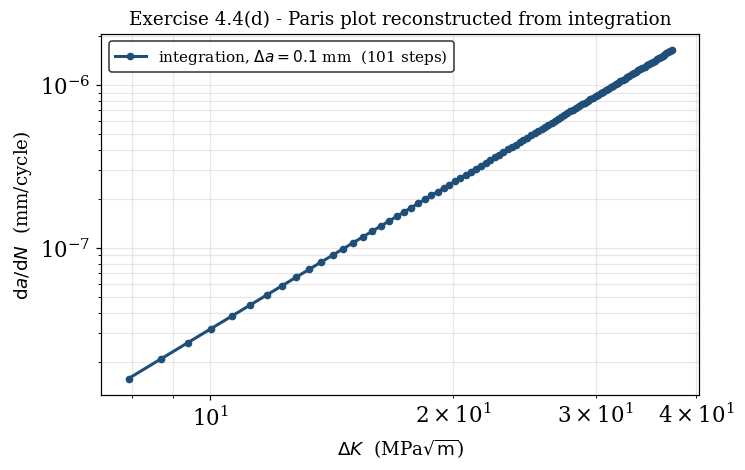

In [8]:
# Exercise 4.4(d) - Paris plot from the canonical integration (delta_a = 0.1 mm)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(dK/SQRT1000, dadN, 'o-', color=COLORS['curve'], lw=2, ms=4,
          label=fr'integration, $\Delta a = 0.1$ mm  ({len(dK)} steps)')
# Overlay the closed-form da/dN = C (Y σ √(π a))^m using the (a, Y) at each step
ax.set_xlabel(r'$\Delta K$  (MPa$\sqrt{\mathrm{m}}$)', fontsize=12)
ax.set_ylabel(r'$\mathrm{d}a/\mathrm{d}N$  (mm/cycle)', fontsize=12)
ax.set_title(r'Exercise 4.4(d) - Paris plot reconstructed from integration', fontsize=12)
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout(); plt.show()


<a id='ex5'></a>
---

## Exercise 4.5 — Paris law recovers the S–N power law

**Paris law recovers the S--N power law**

Consider an infinite plate ($Y = 1$) with a central crack under CA loading. The Paris law is $\mathrm{d}a/\mathrm{d}N = C\,(\Delta K)^m$.

**(a)** Show that by integrating the Paris law from $a_0$ to $a_c$ (with $Y = 1$ and $\Delta K = \Delta\sigma\sqrt{\pi a}$), the fatigue life takes the form:

$$
N_f = \frac{1}{C\,(\Delta\sigma)^m\,\pi^{m/2}} \int_{a_0}^{a_c} a^{-m/2}\,\mathrm{d}a.
$$

**(b)** For $m > 2$ and $a_c \gg a_0$, show that $N_f \approx \text{const.}\times (\Delta\sigma)^{-m}$, which is equivalent to the S--N power-law relation $(\Delta\sigma)^m\,N_f = \text{const}$.

**(c)** Discuss the physical interpretation: the Paris exponent $m$ directly equals the S--N slope exponent when crack initiation is negligible.

### Solution

#### (a) Closed-form integration for $Y=1$

With $\Delta K = \Delta\sigma\sqrt{\pi a}$,

\begin{equation*}
N_{f} = \int_{a_{0}}^{a_{c}}\dfrac{\mathrm{d}a}{C\,(\Delta\sigma\sqrt{\pi a})^{m}}
      = \dfrac{1}{C\,(\Delta\sigma)^{m}\,\pi^{m/2}}\int_{a_{0}}^{a_{c}} a^{-m/2}\,\mathrm{d}a.
\tag{4.5.1}\end{equation*}

#### (b) Asymptotic form for $m>2$ and $a_{c}\gg a_{0}$

For $m\neq 2$,

\begin{equation*}
\int a^{-m/2}\mathrm{d}a = \dfrac{a^{1-m/2}}{1-m/2}.
\tag{4.5.2}\end{equation*}

For $m>2$ the exponent $1-m/2$ is negative, so $a^{1-m/2}$ **decreases** with $a$:
the integral is dominated by the **lower** limit $a_{0}$, and the dependence on
$a_{c}$ vanishes for $a_{c}\gg a_{0}$:

\begin{equation*}
N_{f} \approx \dfrac{a_{0}^{\,1-m/2}}{C\,(m/2-1)\,\pi^{m/2}\,(\Delta\sigma)^{m}}
          \propto (\Delta\sigma)^{-m}.
\tag{4.5.3}\end{equation*}

Hence $(\Delta\sigma)^{m}\,N_{f} = \text{const}$, recovering the Basquin form
with **S–N slope = Paris exponent $m$**.

#### (c) Physical interpretation

If crack initiation is short relative to total life, life is dominated by the
**propagation** phase that follows the Paris law. Then the S–N slope is just
the Paris exponent, with no separate fitting required. This explains why the
S–N exponent of welded details (no initiation) is close to the Paris $m$ of
the parent material.

In [9]:
m_test = 3.0
C_test = 1e-15        # mm/cycle, N*mm^(-1.5)
a0_t, ac_t = 0.5, 40.0
dsigma_arr = np.array([100.0, 150.0, 200.0, 300.0])
Nf = np.empty_like(dsigma_arr, dtype=float)
for i, ds in enumerate(dsigma_arr):
    Nf[i] = (a0_t**(1-m_test/2) - ac_t**(1-m_test/2)) / (
        C_test*(m_test/2 - 1)*(np.pi*ds**2)**(m_test/2))

# Show closed-form components for the first case
exp_half = 1.0 - m_test/2           # = -0.5
print(f'Closed-form (Y=1, m={m_test:.0f}):')
print(f'  N_f = [a0^(1-m/2) - ac^(1-m/2)] / [C*(m/2-1)*(pi*Dsigma^2)^(m/2)]')
print(f'  Exponent 1-m/2 = {exp_half:.2f}')
print(f'  a0^{exp_half:.2f} = {a0_t:.2f}^{exp_half:.2f} = {a0_t**exp_half:.5f}')
print(f'  ac^{exp_half:.2f} = {ac_t:.2f}^{exp_half:.2f} = {ac_t**exp_half:.5f}')
print(f'  Numerator = {a0_t**exp_half:.5f} - {ac_t**exp_half:.5f} = {a0_t**exp_half - ac_t**exp_half:.5f}')
print()
print(f'  {"Dsigma (MPa)":>14}  {"N_f (cycles)":>16}  {"log(Dsigma)":>12}  {"log(N_f)":>12}')
print('  ' + '-'*60)
for ds, nf in zip(dsigma_arr, Nf):
    print(f'  {ds:14.0f}  {nf:16.4e}  {np.log(ds):12.5f}  {np.log(nf):12.5f}')

slope = np.polyfit(np.log(dsigma_arr), np.log(Nf), 1)[0]
print()
print(f'  Log-log slope d(log N_f)/d(log Dsigma) = {slope:.3f}')
print(f'  Theoretical: -m = -{m_test:.1f}   ok')


Closed-form (Y=1, m=3):
  N_f = [a0^(1-m/2) - ac^(1-m/2)] / [C*(m/2-1)*(pi*Dsigma^2)^(m/2)]
  Exponent 1-m/2 = -0.50
  a0^-0.50 = 0.50^-0.50 = 1.41421
  ac^-0.50 = 40.00^-0.50 = 0.15811
  Numerator = 1.41421 - 0.15811 = 1.25610

    Dsigma (MPa)      N_f (cycles)   log(Dsigma)      log(N_f)
  ------------------------------------------------------------
             100        4.5116e+08       4.60517      19.92733
             150        1.3368e+08       5.01064      18.71093
             200        5.6395e+07       5.29832      17.84789
             300        1.6710e+07       5.70378      16.63149

  Log-log slope d(log N_f)/d(log Dsigma) = -3.000
  Theoretical: -m = -3.0   ok


<a id='ex6'></a>
---

## Exercise 4.6 — Incremental crack growth with width correction

**Incremental crack growth with width correction**

A sheet of width $W = 160$ mm contains a central hole of diameter $D = 8$ mm with two symmetric edge cracks of initial length $a_0 = 4$ mm (effective initial crack: $a_{\text{eff},0} = a_0 + D/2 = 8$ mm). The sheet is loaded under CA with $R = 0$, $S_{\max} = 80$ MPa. Crack growth data for the material are available from the Schijve textbook (Figure E8.11b).

**(a)** Predict the crack growth from $a = 4$ mm to $a = 36$ mm using incremental steps of $\Delta a = 4$ mm. Apply the Feddersen width correction at each step. Tabulate: $a_i$, $a_{\text{eff},i}$, $Y(a_{\text{eff},i}/W)$, $\Delta K_i$, $(\mathrm{d}a/\mathrm{d}N)_i$, $\Delta N_i$, $\sum N$.

**(b)** Plot $a$ vs. $N$ and comment on the acceleration of crack growth as $a \to W/2$.

**(c)** Extract the Paris constants $C$ and $m$ from the $\mathrm{d}a/\mathrm{d}N$ vs. $\Delta K$ data by log--log regression.

**(d)** Compare the $Y(a/W)$ correction obtained with the Feddersen formula against the simpler approximation $Y = 1$. How much does the fatigue life change?

### Solution

#### (a)–(b) Forward integration to $a_{\text{eff}}=W/2$

We use a generic Paris fit (illustrative, mimicking Schijve Fig. E8.11b):
$C = 1.0\times 10^{-12}$ m/cycle, $m=3$, with $\Delta K$ in MPa√m. The
Feddersen correction (F.2) is applied at each step on the effective crack
length.

In [10]:
W6    = 160.0                          # mm
D6    = 8.0                            # mm  (hole diameter)
a0_6  = 4.0                            # mm  (initial edge crack from hole face)
a_eff0 = a0_6 + D6/2                   # mm  (effective crack = a + D/2)
S_max = 80.0                           # MPa
R6    = 0.0
dsigma = S_max*(1 - R6)               # MPa
C6, m6 = 1.0e-12, 3.0                 # m/cycle, MPa*sqrt(m)

print(f'Geometry:  W = {W6} mm,  D = {D6} mm')
print(f'Initial:   a_0 = {a0_6} mm  (crack from hole face)')
print(f'           a_eff = a_0 + D/2 = {a0_6} + {D6/2} = {a_eff0} mm  (effective half-crack)')
print(f'Loading:   S_max = {S_max} MPa,  R = {R6:.1f},  Dsigma = {dsigma} MPa')
print(f'Paris:     C = {C6:.0e} m/cycle (MPa*sqrt(m)),  m = {m6}')
print()

def DK_MPa_sqrt_m(a_eff_mm, W_mm, dsigma_MPa):
    aw = a_eff_mm / W_mm
    Y  = float(Y_feddersen_DK(aw))
    return Y, Y*dsigma_MPa*np.sqrt(np.pi*a_eff_mm*1e-3)    # MPa*sqrt(m)

a_eff = a_eff0
N     = 0.0
records = []
da = 4.0                                # mm step
while a_eff < 0.45*W6:
    Y, dK = DK_MPa_sqrt_m(a_eff, W6, dsigma)
    dadN_m = C6*dK**m6                  # m/cycle
    dadN   = dadN_m*1e3                 # mm/cycle
    dN     = da/dadN
    records.append((a_eff, Y, dK, dadN, dN, N))
    N    += dN
    a_eff += da

print(f'{"a_eff (mm)":>10s} {"Y":>7s} {"DK (MPa*sqrt(m))":>16s} {"da/dN (mm/cyc)":>16s} {"dN":>14s} {"sum_N":>14s}')
for a, Y, dK, dr, dN, Ncum in records:
    print(f'{a:10.2f} {Y:7.4f} {dK:16.3f} {dr:16.3e} {dN:14.1f} {Ncum:14.1f}')
print(f'\nFinal: a_eff = {a_eff:.1f} mm, total N = {N:.0f} cycles')


Geometry:  W = 160.0 mm,  D = 8.0 mm
Initial:   a_0 = 4.0 mm  (crack from hole face)
           a_eff = a_0 + D/2 = 4.0 + 4.0 = 8.0 mm  (effective half-crack)
Loading:   S_max = 80.0 MPa,  R = 0.0,  Dsigma = 80.0 MPa
Paris:     C = 1e-12 m/cycle (MPa*sqrt(m)),  m = 3.0

a_eff (mm)       Y DK (MPa*sqrt(m))   da/dN (mm/cyc)             dN          sum_N
      8.00  1.0060           12.758        2.077e-06      1926096.6            0.0
     12.00  1.0136           15.744        3.902e-06      1025024.2      1926096.6
     16.00  1.0245           18.375        6.204e-06       644722.9      2951120.8
     20.00  1.0390           20.835        9.045e-06       442257.1      3595843.7
     24.00  1.0575           23.231        1.254e-05       319058.3      4038100.8
     28.00  1.0806           25.640        1.686e-05       237299.5      4357159.0
     32.00  1.1090           28.131        2.226e-05       179676.4      4594458.6
     36.00  1.1438           30.772        2.914e-05       137269

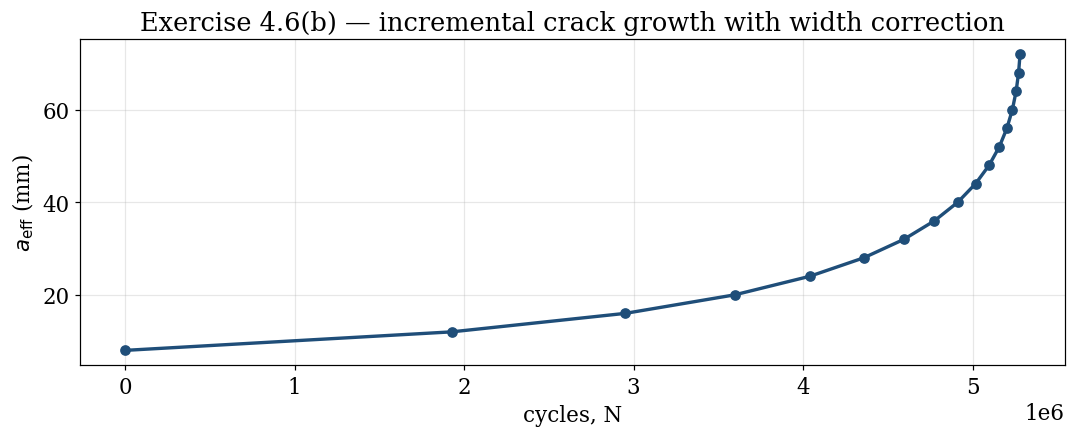

In [11]:
# Plot a vs N
a_list = [r[0] for r in records] + [a_eff]
N_list = [r[5] for r in records] + [N]
fig, ax = plt.subplots()
ax.plot(N_list, a_list, 'o-', color=COLORS['curve'], lw=2.2, markersize=6)
ax.set_xlabel('cycles, N'); ax.set_ylabel(r'$a_{\rm eff}$ (mm)')
ax.set_title('Exercise 4.6(b) — incremental crack growth with width correction')
plt.tight_layout(); plt.show()


#### (c) Extracting Paris $C,m$ from the $\mathrm{d}a/\mathrm{d}N$ vs $\Delta K$ table

Log–log linear regression.

In [12]:
arr      = np.array(records)
dK_arr   = arr[:,2]                    # MPa*sqrt(m)
dadN_arr = arr[:,3]                    # mm/cycle

log_C, slope = np.polyfit(np.log(dK_arr), np.log(dadN_arr), 1)[::-1]
C_fit = np.exp(log_C)
m_fit = slope

print(f'(c) Log-log regression: log(da/dN) = log(C) + m*log(DK)')
print(f'    First data point:  DK = {dK_arr[0]:.3f} MPa*sqrt(m),  da/dN = {dadN_arr[0]:.3e} mm/cycle')
print(f'    Last  data point:  DK = {dK_arr[-1]:.3f} MPa*sqrt(m),  da/dN = {dadN_arr[-1]:.3e} mm/cycle')
print(f'    Fitted log(C) = {log_C:.5f}  =>  C = exp({log_C:.5f}) = {C_fit:.3e} (mm/cycle, MPa*sqrt(m))')
print(f'    Fitted m      = {m_fit:.3f}')
print(f'    Verification: input C6 = 1e-12 m/cycle = 1e-9 mm/cycle  ->  matches C_fit = {C_fit:.3e}')
print(f'    Input m6 = 3.0  ->  matches m_fit = {m_fit:.3f}')


(c) Log-log regression: log(da/dN) = log(C) + m*log(DK)
    First data point:  DK = 12.758 MPa*sqrt(m),  da/dN = 2.077e-06 mm/cycle
    Last  data point:  DK = 77.544 MPa*sqrt(m),  da/dN = 4.663e-04 mm/cycle
    Fitted log(C) = -20.72327  =>  C = exp(-20.72327) = 1.000e-09 (mm/cycle, MPa*sqrt(m))
    Fitted m      = 3.000
    Verification: input C6 = 1e-12 m/cycle = 1e-9 mm/cycle  ->  matches C_fit = 1.000e-09
    Input m6 = 3.0  ->  matches m_fit = 3.000


#### (d) Comparison with $Y=1$

In [13]:
# Re-run with Y=1 (infinite plate, no width correction)
a_eff = a_eff0; N_inf = 0.0
while a_eff < 0.45*W6:
    dK   = 1.0*dsigma*np.sqrt(np.pi*a_eff*1e-3)
    dadN = C6*dK**m6 * 1e3
    N_inf += da/dadN
    a_eff += da
print(f'(d) With Y(a/W) (Feddersen)  : N ≈ {N:.0f} cycles')
print(f'    With Y = 1 (infinite)    : N ≈ {N_inf:.0f} cycles')
print(f'    Difference               : {(N_inf - N)/N*100:+.1f}%  '
      f'(Y>1 in the late stage shortens the life)')


(d) With Y(a/W) (Feddersen)  : N ≈ 5279074 cycles
    With Y = 1 (infinite)    : N ≈ 6290942 cycles
    Difference               : +19.2%  (Y>1 in the late stage shortens the life)


---

### Final remarks

* All life predictions follow the Paris-law integration (F.3). The choice of
  $\Delta K$ shape function (Y-correction) is critical when the crack
  approaches the boundary, $a/W\gtrsim 0.3$.
* The Paris-law/S–N equivalence (Ex 4.5) explains why the S–N exponent and the
  Paris exponent are close in many engineering data sets, *provided that
  initiation is short*.
* Closure (Ex 4.3) is the dominant physical reason for the $R$-dependence
  observed in long-crack data; collapsing data through $\Delta K_{\text{eff}}$ is
  one of the major design simplifications of the field.

---

Copyright (c) DEMI - NOVA FCT

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>

Parts of this notebook were prepared with AI assistance (<a href="https://www.anthropic.com/claude-code" target="_blank">Claude Code</a>, Anthropic), reviewed and verified by the author.